Sean X,Y variables aleatorias tal que la función de distribución conjuntas es

H(x,y)= \begin{cases}
\frac{(x+1)(e^y-1)}{x + 2e^y - 1}, & (x,y) \in [-1,1] \times [0,\infty], \\
1 - e^{-y}, & (x,y) \in (1,\infty] \times [0,\infty], \\
0, & \text{otros casos}.
\end{cases}

La copula C de X,Y es

$C(u,v)= \frac{uv}{u+v-uv}$

Un algoritmo para generar variables aleatorias $(x,y)$ es:
1. Generar 2 variables $u,t$ uniformes independientes $(0,1)$
2. Hacer $v=\frac{u\sqrt{t}}{1-(1-u)\sqrt{t}}$
3. Inversas de las distribuciones marginales
$x=2u-1$ y $y=-ln(1-v)$

4. Obtener un par $(x,y)$

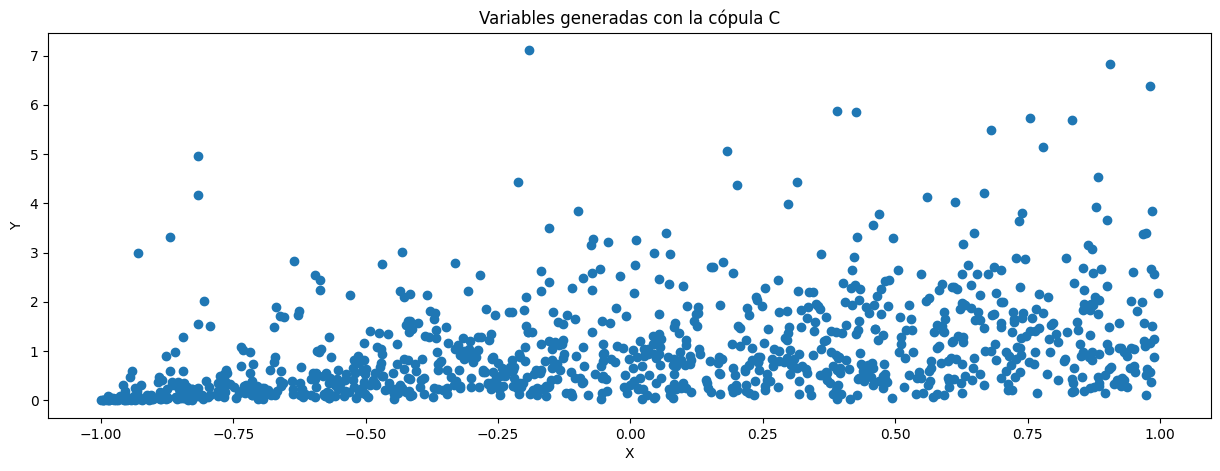

In [1]:
import numpy as np
import matplotlib.pyplot as plt
n=1000
def inverse():# Función donde generamos los valores de x,y
  t=np.random.uniform(0,1)
  u=np.random.uniform(0,1)

  v= (u*np.sqrt(t))/(1-(1-u)*np.sqrt(t))

  x_val=2*u-1
  y_val=-np.log(1-v)
  return x_val,y_val

pares=[inverse() for _ in range(n)] #Se repite la función 100 veces
x,y=zip(*pares)

plt.figure(figsize=(15, 5))
plt.scatter(x, y)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Variables generadas con la cópula C')
plt.show()

# Copula de supervivencia
Se utilizan en el método de función de distribución condicional para generar variables aleatorias a partir de una distribución con una función de supervivencia dada donde la copula $C$ es la función de distribución de los pares $(U,V)$ que le corresponde una función cópula de supervivenincia $\hat{C}(u,v)=u+v-1+C(1-u,1-v)$ cuya función de distribución es la copula C, dada $\hat{C}$
1. Generar dos variables uniformes independientes $u,t$ entre $(0,1)$
2. Hacer $v=\hat{c}_u^{-1}(t)$, tal que $\hat{c}_u^{-1}$ denota la cuasi-inversa de $\hat{c}_u(v)=\frac{\partial\hat{C}(u,v)}{\partial u}$
3. Obtener el par $(u,v)$

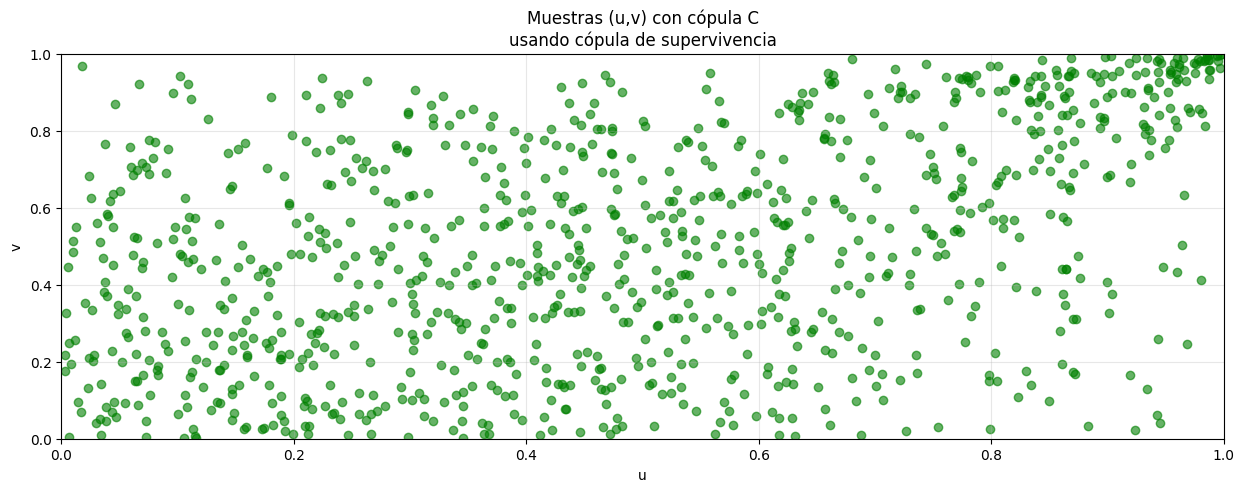

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

u_sym, v_sym, t_sym = sp.symbols('u v t') # Variables simbólicas
copula_C_sym = (u_sym * v_sym) / (u_sym + v_sym - u_sym * v_sym) # Copula original
copula_sup_sym = u_sym + v_sym - 1 + ((1 - u_sym)*(1 - v_sym)) / ((1 - u_sym) + (1 - v_sym) - (1 - u_sym)*(1 - v_sym)) # Cópula de supervivencia
copula_parcial_sup_sym = sp.diff(copula_sup_sym, u_sym) # Derivada parcial de Ĉ con respecto a u
ecuacion = sp.Eq(copula_parcial_sup_sym, t_sym)
v_solucion = sp.solve(ecuacion, v_sym)
v_inversa_sym = v_solucion[1]  # Da 2 soluciones, tomamos la válida en [0,1]
v_inversa = sp.lambdify((u_sym, t_sym), v_inversa_sym, "numpy")


def generar_pares():
    u = np.random.uniform(0, 1)
    t = np.random.uniform(0, 1)
    v = v_inversa(u,t)
    return u, v

pares_sup = [generar_pares() for _ in range(n)]
u_vals, v_vals = zip(*pares_sup)

plt.figure(figsize=(15, 5))
plt.scatter(u_vals, v_vals, alpha=0.6, color='green')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Muestras (u,v) con cópula C\nusando cópula de supervivencia')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()


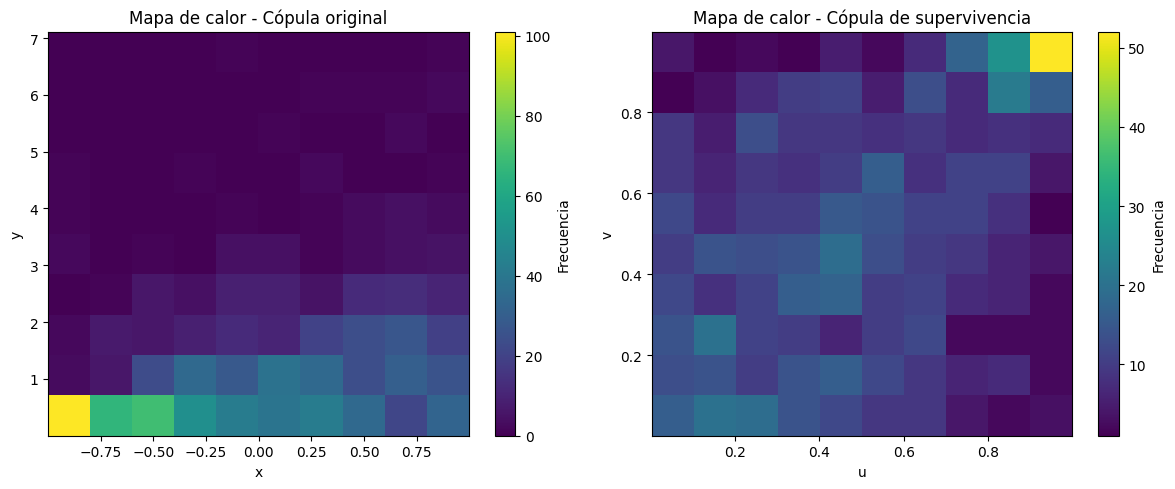

In [3]:
plt.figure(figsize=(12,5))

# Cópula original
plt.subplot(1,2,1)
plt.hist2d(x, y)
plt.colorbar(label="Frecuencia")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Mapa de calor - Cópula original")

# Cópula de supervivencia
plt.subplot(1,2,2)
plt.hist2d(u_vals, v_vals)

plt.colorbar(label="Frecuencia")
plt.xlabel("u")
plt.ylabel("v")
plt.title("Mapa de calor - Cópula de supervivencia")

plt.tight_layout()
plt.show()
